# Phase 2 Bounded Projected-Depth Semantic Occupancy IoU

This notebook runs a bounded streamed CARLA validation evaluation and inspects the artifacts produced by `src.evaluation.phase2_carla_eval`.

Important: these are **bounded projected-depth semantic occupancy IoU** results. The target proxy is built from LiDAR-converted projected depth plus front semantic segmentation, not dense simulator 3D occupancy ground truth.

## 1. Setup

In [1]:
from __future__ import annotations

import json
from pathlib import Path

from IPython.display import Image, Markdown, display

from src.evaluation.phase2_carla_eval import (
    Phase2CarlaEvalConfig,
    iter_shadow_records,
    run_bounded_carla_iou_evaluation,
)

MAX_FRAMES = 200
OUTPUT_DIR = Path("outputs/phase2")
OCCUPANCY_THRESHOLD = 0.25
DISAGREEMENT_THRESHOLD = 0.05

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

## 2. Run Bounded Evaluation

In [2]:
config = Phase2CarlaEvalConfig(
    max_frames=MAX_FRAMES,
    output_dir=OUTPUT_DIR,
    occupancy_threshold=OCCUPANCY_THRESHOLD,
    disagreement_threshold=DISAGREEMENT_THRESHOLD,
    bev_frame_count=5,
)

artifacts = run_bounded_carla_iou_evaluation(config=config)
for name, path in artifacts.__dict__.items():
    print(f"{name}: {path}")

d:\carla\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


baseline_iou: outputs\phase2\carla_baseline_iou_summary.json
temporal_iou: outputs\phase2\carla_temporal_iou_summary.json
shadow_records: outputs\phase2\carla_shadow_mode_records.jsonl
shadow_clusters: outputs\phase2\carla_shadow_mode_clusters.json
run_summary: outputs\phase2\carla_evaluation_run_summary.json
bev_images: (WindowsPath('outputs/phase2/bev/bev_frame_00000_0.png'), WindowsPath('outputs/phase2/bev/bev_frame_00001_5.png'), WindowsPath('outputs/phase2/bev/bev_frame_00002_10.png'), WindowsPath('outputs/phase2/bev/bev_frame_00003_15.png'), WindowsPath('outputs/phase2/bev/bev_frame_00004_20.png'), WindowsPath('outputs/phase2/bev/bev_frame_00005_25.png'), WindowsPath('outputs/phase2/bev/bev_frame_00006_30.png'))


## 3. IoU Table

In [3]:
baseline = json.loads(artifacts.baseline_iou.read_text(encoding="utf-8"))
temporal = json.loads(artifacts.temporal_iou.read_text(encoding="utf-8"))
run_summary = json.loads(artifacts.run_summary.read_text(encoding="utf-8"))

baseline_by_class = {row["class_id"]: row for row in baseline["classes"]}
temporal_by_class = {row["class_id"]: row for row in temporal["classes"]}

lines = ["| class_name | baseline_iou | temporal_iou | delta |", "|---|---:|---:|---:|"]
for class_id, base_row in baseline_by_class.items():
    temp_row = temporal_by_class[class_id]
    delta = temp_row["iou"] - base_row["iou"]
    lines.append(
        f"| {base_row['class_name']} | {base_row['iou']:.3f} | "
        f"{temp_row['iou']:.3f} | {delta:+.3f} |"
    )

display(Markdown("\n".join(lines)))
display(Markdown(f"**Processed frames:** {run_summary['processed_frame_count']} / requested {run_summary['requested_max_frames']}"))
display(Markdown(f"**Target proxy:** {run_summary['target_proxy']}"))
display(Markdown(f"**Free-space note:** {run_summary['free_space_note']}"))

| class_name | baseline_iou | temporal_iou | delta |
|---|---:|---:|---:|
| pedestrian | 1.000 | 1.000 | +0.000 |
| road | 1.000 | 0.502 | -0.498 |
| vehicle | 1.000 | 0.569 | -0.431 |

**Processed frames:** 200 / requested 200

**Target proxy:** current-frame occupancy grid from LiDAR-converted projected depth and front semantic segmentation; this is not dense simulator 3D ground truth

**Free-space note:** Free space IoU is not reported because this occupancy representation stores observed occupied voxels and does not raycast explicit free-space labels.

## 4. Shadow-Mode Summary

In [4]:
records = list(iter_shadow_records(artifacts.shadow_records))
clusters = json.loads(artifacts.shadow_clusters.read_text(encoding="utf-8"))
rates = [record["disagreement_rate"] for record in records]
flagged = [record for record in records if record["flagged"]]

summary_lines = [
    f"- Evaluated frames: `{len(records)}`",
    f"- Flagged frames: `{len(flagged)}`",
    f"- Mean disagreement: `{(sum(rates) / len(rates)) if rates else 0.0:.4f}`",
    f"- Max disagreement: `{max(rates) if rates else 0.0:.4f}`",
    f"- Disagreement threshold: `{clusters['disagreement_threshold']}`",
]
display(Markdown("\n".join(summary_lines)))
display(Markdown("```json\n" + json.dumps(clusters["clusters"], indent=2) + "\n```"))

- Evaluated frames: `200`
- Flagged frames: `199`
- Mean disagreement: `0.4391`
- Max disagreement: `0.6493`
- Disagreement threshold: `0.05`

```json
{
  "weather": {
    "adverse": 199
  },
  "lighting": {
    "low_sun": 199
  },
  "traffic": {
    "light": 199
  },
  "speed": {
    "low_speed": 199
  }
}
```

## 5. Visual Checks

**bev_frame_00000_0.png**

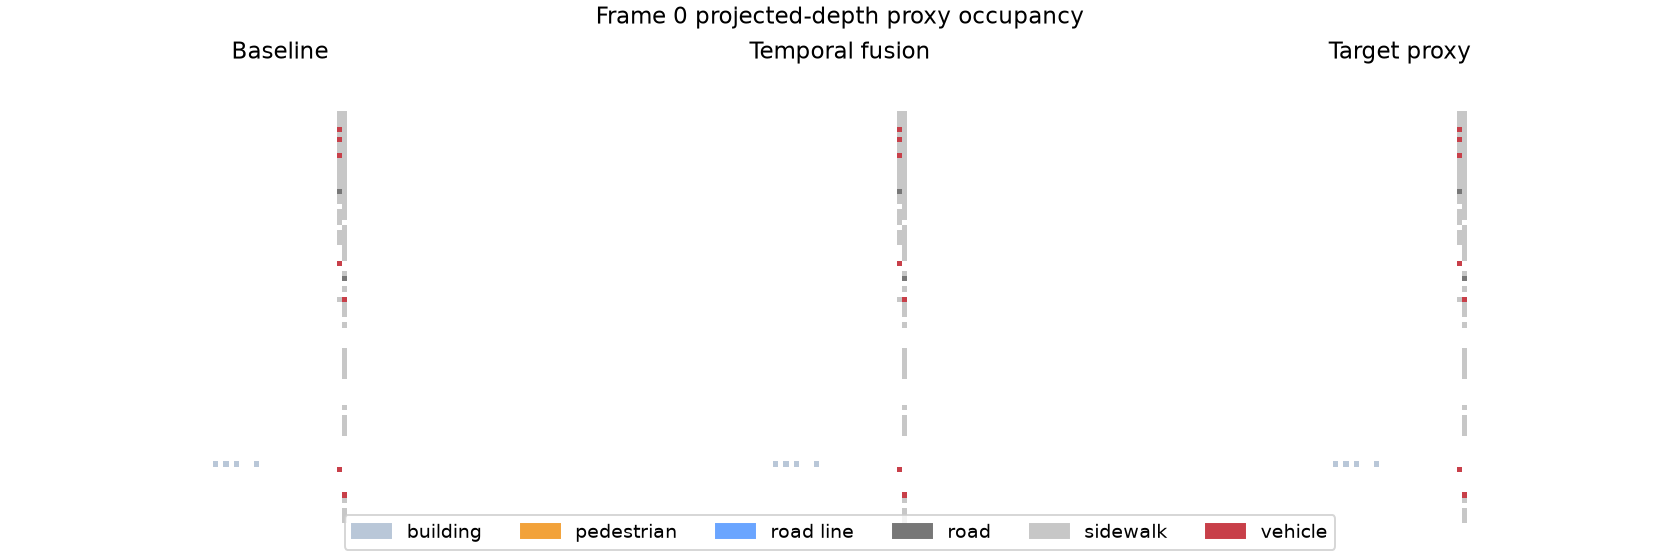

**bev_frame_00001_5.png**

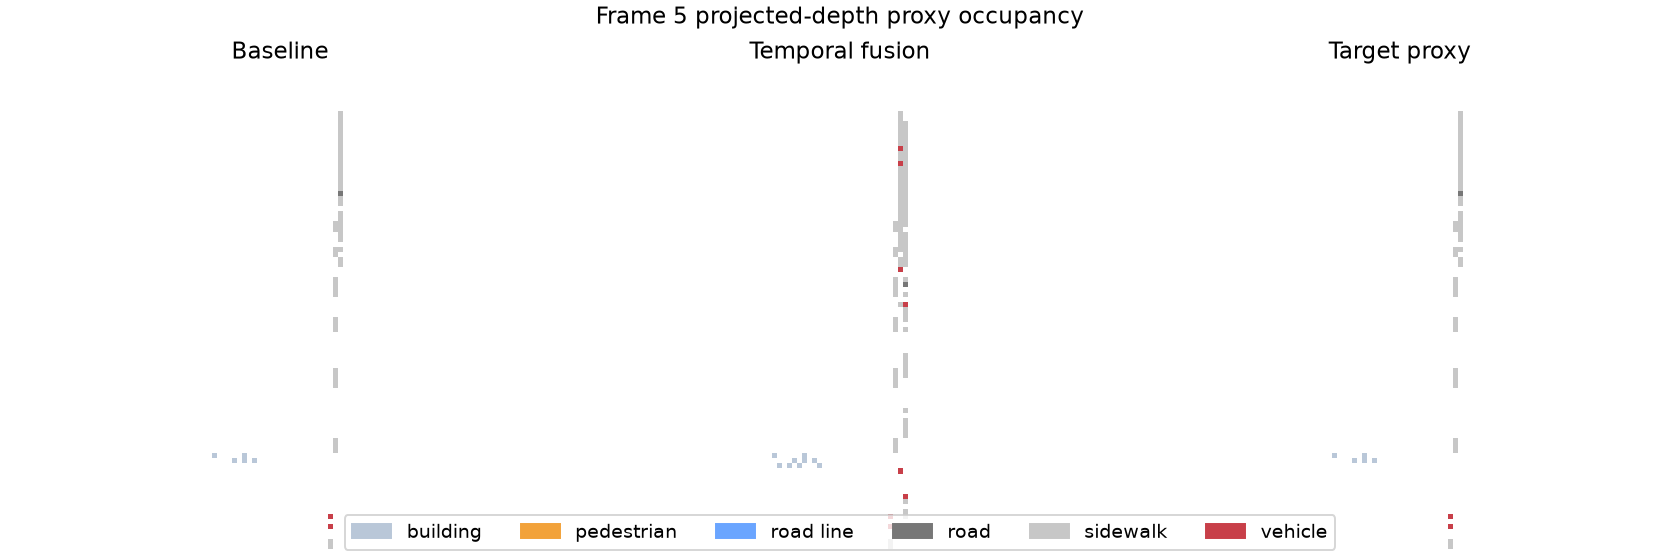

**bev_frame_00002_10.png**

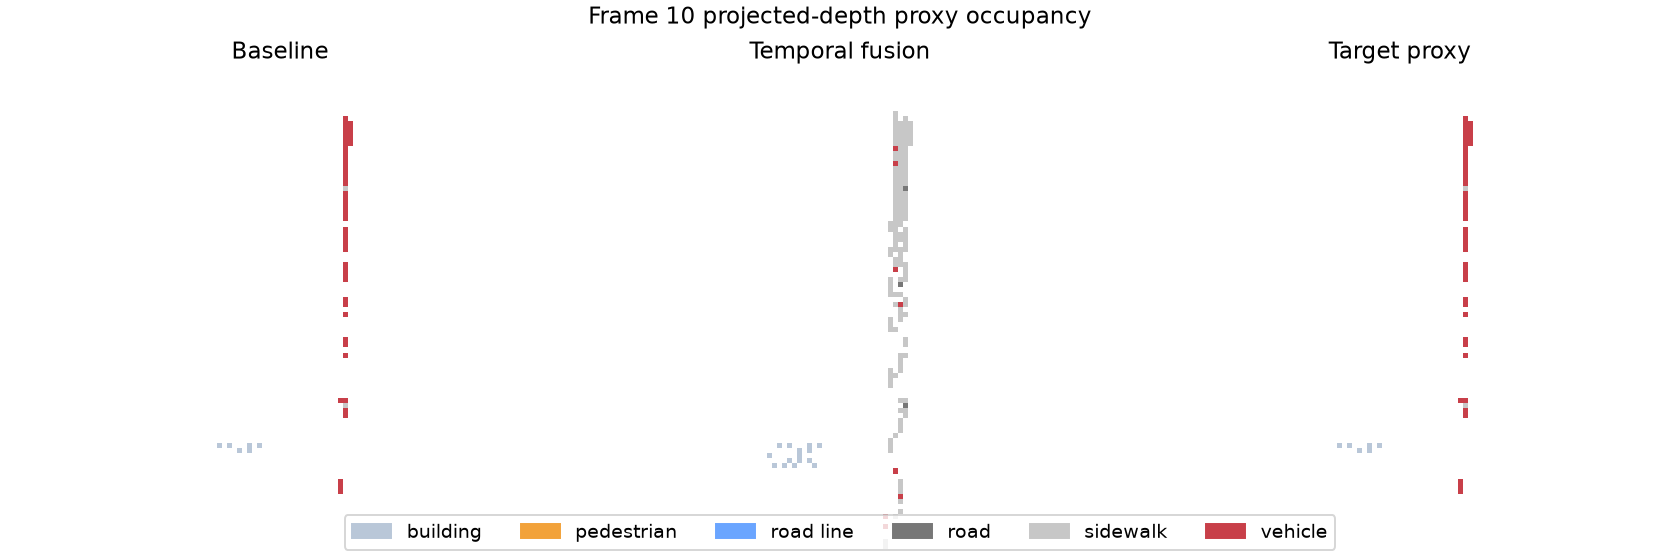

**bev_frame_00003_15.png**

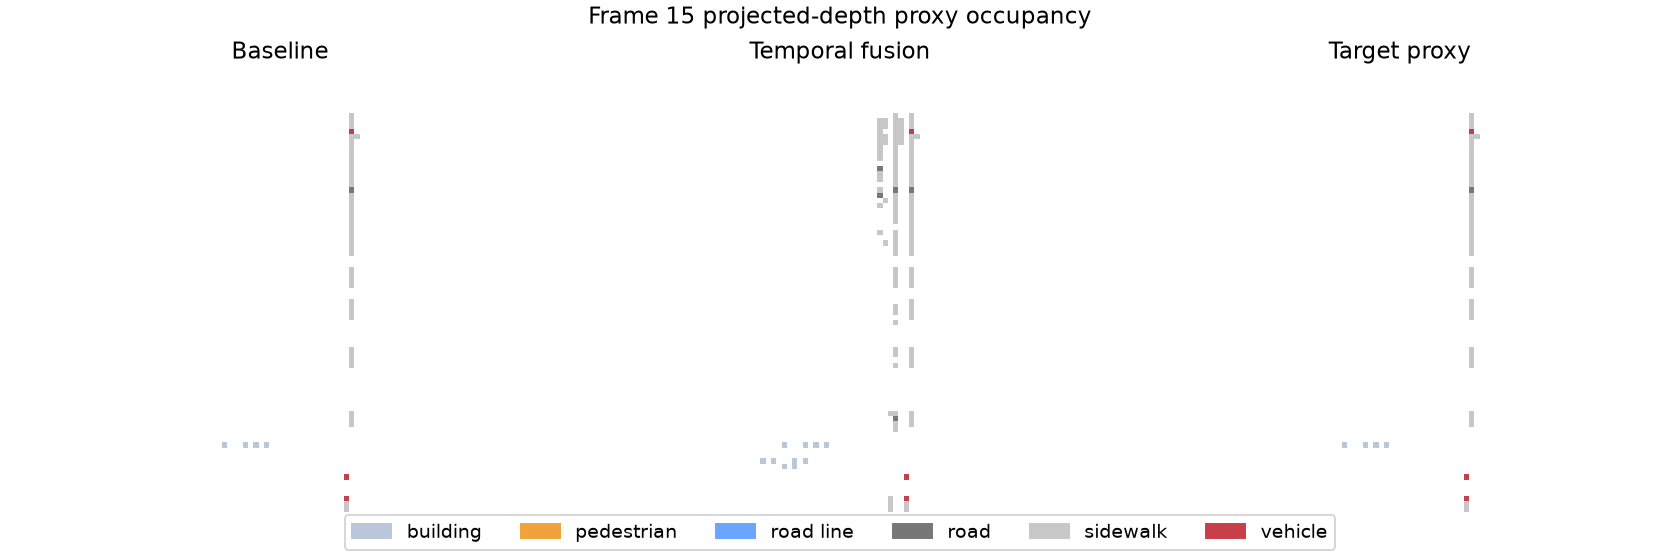

**bev_frame_00004_20.png**

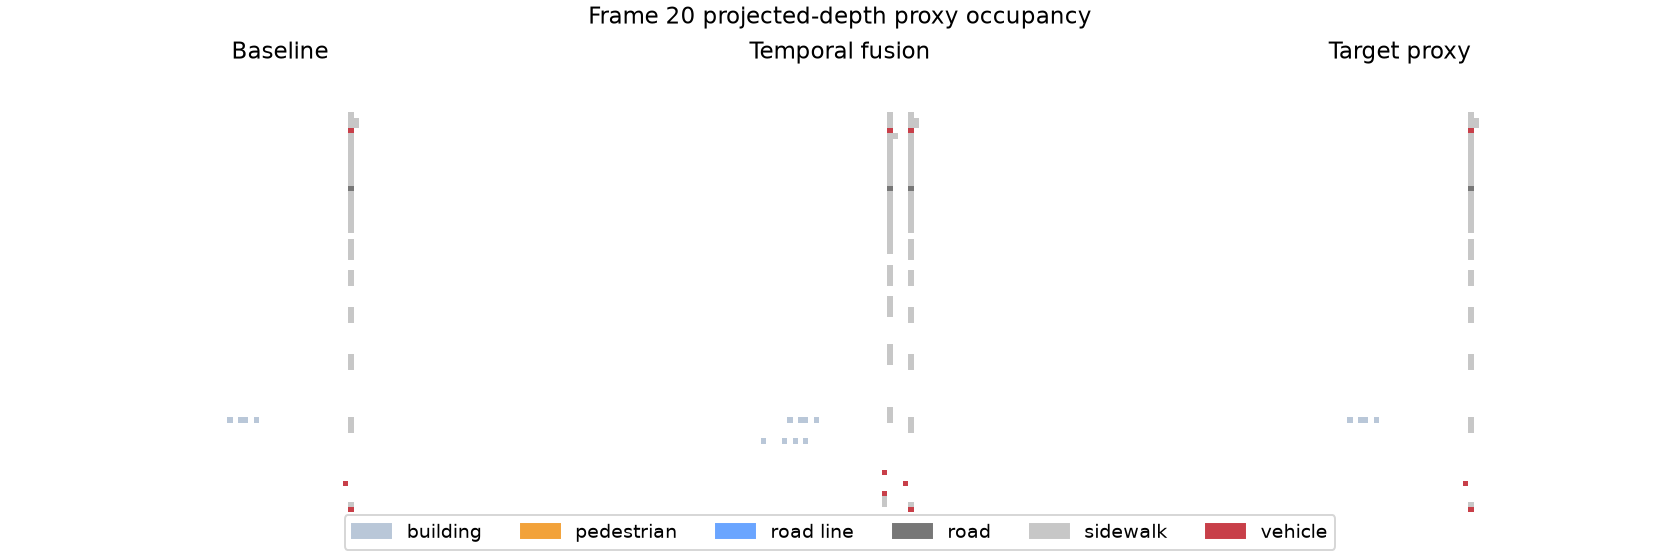

In [5]:
for image_path in artifacts.bev_images[:5]:
    display(Markdown(f"**{image_path.name}**"))
    display(Image(filename=str(image_path)))

## 6. Interpretation Notes

In [6]:
notes = []
for class_id, base_row in baseline_by_class.items():
    temp_row = temporal_by_class[class_id]
    delta = temp_row["iou"] - base_row["iou"]
    if delta >= 0:
        notes.append(f"- `{base_row['class_name']}` temporal IoU preserved or improved by `{delta:+.3f}` against the current-frame proxy.")
    else:
        notes.append(f"- `{base_row['class_name']}` temporal IoU is `{delta:+.3f}` lower against the current-frame proxy; this can happen when fusion retains older sparse LiDAR evidence that is absent from the proxy target.")

notes.extend([
    "- Baseline IoU is expected to be high because the proxy target is built from the current frame's own projected depth and segmentation.",
    "- Temporal-vs-proxy IoU measures agreement with the current sparse observation, not whether temporal memory is useful.",
    "- Vehicle and pedestrian IoU may be noisy because the depth source is sparse 32-channel LiDAR projected into the front camera.",
    "- Shadow-mode clusters are failure-mode hints, not final causal claims.",
])
display(Markdown("\n".join(notes)))

- `pedestrian` temporal IoU preserved or improved by `+0.000` against the current-frame proxy.
- `road` temporal IoU is `-0.498` lower against the current-frame proxy; this can happen when fusion retains older sparse LiDAR evidence that is absent from the proxy target.
- `vehicle` temporal IoU is `-0.431` lower against the current-frame proxy; this can happen when fusion retains older sparse LiDAR evidence that is absent from the proxy target.
- Baseline IoU is expected to be high because the proxy target is built from the current frame's own projected depth and segmentation.
- Temporal-vs-proxy IoU measures agreement with the current sparse observation, not whether temporal memory is useful.
- Vehicle and pedestrian IoU may be noisy because the depth source is sparse 32-channel LiDAR projected into the front camera.
- Shadow-mode clusters are failure-mode hints, not final causal claims.